# Student Information

**Full name:** Amirhosein Rezaei

**Student number:** 401105989

---

# Homework — The Mechanics of Diffusion-Based Image Editing
### Latent space, the noise schedule, the reverse process, classifier-free guidance, and CLIP conditioning

**Free on a Colab T4. Open weights only — no paid API, no cloud billing.**

Instead of treating the model as a black box, you will **take a latent-diffusion model apart** and rebuild its sampling loop by hand, then use that understanding to edit images.

You touch these deep-learning concepts directly:
| Part | DL concept |
|---|---|
| 1 | Autoencoders / **VAE** latent compression, reconstruction error (PSNR) |
| 2 | **Forward diffusion** $q(x_t\mid x_0)$, noise schedule, signal-to-noise ratio |
| 3 | **Reverse process**: U-Net ε-predictor + sampler (DDIM), hand-written loop |
| 4 | **Classifier-free guidance** — derive and implement the guidance equation |
| 5 | **Conditioning**: CLIP text embeddings, cross-attention, embedding interpolation |
| 6 | **Applications**: instruction editing (InstructPix2Pix) + inpainting |

**Estimated time: 3-4 h.** Set `Runtime > Change runtime type > T4 GPU` first.

## Part 0 — Setup

In [1]:
# Pinned for reproducibility. On a torch mismatch: Runtime > Restart session, then re-run.
%pip install -q "diffusers==0.31.0" "transformers==4.44.2" \
    "accelerate==0.34.2" "safetensors>=0.4.2" "huggingface_hub==0.25.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.6/436.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 82.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.25.2 which is incompatible.


### Hugging Face login (required)
Colab's shared IPs are rate-limited by the Hub, so **anonymous** downloads fail with `401`. Authenticate with a free token:
1. Create a **Read** token at https://huggingface.co/settings/tokens
2. In Colab, click the 🔑 (**Secrets**) icon in the left sidebar → **Add new secret** → name it `HF_TOKEN`, paste the token, and enable **Notebook access**.
3. Run the next cell. (Never paste the token directly into code.)

In [2]:
from huggingface_hub import login
try:
    from google.colab import userdata
    login(userdata.get('HF_TOKEN'))          # reads the Colab secret named HF_TOKEN
except Exception as e:
    print('Colab secret not found; falling back to manual login.')
    login()                                   # paste your Read token when prompted
print('Hugging Face login OK')

Colab secret not found; falling back to manual login.


Hugging Face login OK


In [3]:
import torch, math, time
import matplotlib.pyplot as plt
print('CUDA:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'Enable GPU: Runtime > Change runtime type > T4 GPU'
print('GPU:', torch.cuda.get_device_name(0))
DEVICE, DTYPE = 'cuda', torch.float16

CUDA: True
GPU: Tesla T4


In [4]:
import io, requests
from PIL import Image
from torchvision import transforms as T

to_tensor, to_pil = T.ToTensor(), T.ToPILImage()

def load_image(url_or_path, size=(512, 512)):
    if str(url_or_path).startswith('http'):
        img = Image.open(io.BytesIO(requests.get(url_or_path, timeout=30).content))
    else:
        img = Image.open(url_or_path)
    return img.convert('RGB').resize(size)

def show(*imgs, titles=None):
    n = len(imgs); fig, ax = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
    ax = [ax] if n == 1 else ax
    for a, im in zip(ax, imgs):
        a.imshow(im); a.axis('off')
    if titles:
        for a, t in zip(ax, titles): a.set_title(t, fontsize=10)
    plt.show()

def free_memory(*objs):
    for o in objs:
        del o
    import gc; gc.collect(); torch.cuda.empty_cache()

### Load a base latent-diffusion model and expose its components
Stable Diffusion is a **latent** diffusion model with four pieces: a **VAE** (`vae`), a **U-Net** noise predictor (`unet`), a **CLIP text encoder** (`text_encoder` + `tokenizer`), and a **scheduler** (the sampler). We grab them individually so we can drive the process ourselves.

In [5]:
from diffusers import StableDiffusionPipeline, DDIMScheduler

# NOTE: the official 'stabilityai/stable-diffusion-2-1-base' repo was deprecated/removed
# from the Hub (returns 404). We use a community mirror with identical weights.
pipe = StableDiffusionPipeline.from_pretrained(
    'Manojb/stable-diffusion-2-1-base', torch_dtype=DTYPE).to(DEVICE)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe.set_progress_bar_config(disable=True)

vae, unet = pipe.vae, pipe.unet
text_encoder, tokenizer, scheduler = pipe.text_encoder, pipe.tokenizer, pipe.scheduler
print('unet in_channels:', unet.config.in_channels,
      '| latent scale factor:', vae.config.scaling_factor,
      '| train timesteps:', scheduler.config.num_train_timesteps)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.36G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


unet in_channels: 4 | latent scale factor: 0.18215 | train timesteps: 1000


## Part 1 — The latent space (the VAE)
Diffusion here does **not** run on pixels. The VAE encoder maps a `3x512x512` image to a `4x64x64` **latent**, and the decoder maps it back. Everything in Parts 2-6 happens in that small latent space.

In [6]:
@torch.no_grad()
def encode(img):
    x = to_tensor(load_image(img) if isinstance(img, str) else img)
    x = (x * 2 - 1).unsqueeze(0).to(DEVICE, DTYPE)
    lat = vae.encode(x).latent_dist.sample()
    return lat * vae.config.scaling_factor

@torch.no_grad()
def decode(lat):
    x = vae.decode(lat / vae.config.scaling_factor).sample
    x = (x / 2 + 0.5).clamp(0, 1)[0].float().cpu()
    return to_pil(x)

### Task 1.1 — Measure the compression
> **TODO:** Encode any image and print (a) the pixel tensor shape `3x512x512`, (b) the latent shape, and (c) the **compression ratio** = pixel elements / latent elements.

In [7]:
img = load_image('https://huggingface.co/datasets/hf-internal-testing/diffusers-images/'
                 'resolve/main/in_paint/overture-creations-5sI6fQgYIuo.png')
z = encode(img)
pixels = 3 * 512 * 512
latent = z.numel()
print(pixels)
print(z.shape)
print(pixels / latent)


786432
torch.Size([1, 4, 64, 64])
48.0


### Task 1.2 — Reconstruction error
The VAE is *lossy*. Round-trip the image (encode then decode), show both, and compute **PSNR**.
> **TODO:** Complete the PSNR function and report the value.

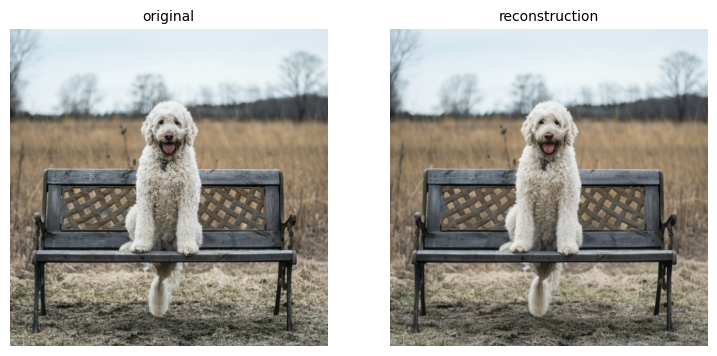

25.666139074828127


In [8]:
import numpy as np
def psnr(a, b):
    a = np.asarray(a, np.float32) / 255; b = np.asarray(b, np.float32) / 255
    mse = ((a - b) ** 2).mean()
    return float('inf') if mse == 0 else 10 * math.log10(1.0 / mse)

recon = decode(z)
show(img, recon, titles=['original', 'reconstruction'])
print(psnr(img, recon))


> **Q1.** A pixel-space diffusion model would denoise a `3x512x512` tensor at every step; this model denoises `4x64x64`. Using your compression ratio, explain *quantitatively* why latent diffusion is so much cheaper, and state what is sacrificed (use your PSNR number).

*Your answer to Q1:*

latent is 4x64x64 = 16384 elements v.s. 3x512x512 = 786432 pixel elements that is a compression ratio of 48x and since U Net per step compute and memory scale with the spatial size of its input running the denoiser on a 4x64x64 tensor instead of a 3x512x512 tensor cuts FLOPs and activation memory by roughly the same around 48x factor at every one of the (many) sampling steps which is what makes running dozens of diffusion steps on a single T4 GPU practical and the thing that sacrificed is exactness of reconstruction that VAE is lossy so encoding then decoding the image does not return the original pixels exactly and measured PSNR is finite rather than infinite that is meaning fine high frequency detail and texture are discarded during compression into the latent space


## Part 2 — The forward diffusion process
The forward process gradually destroys a latent with Gaussian noise:

$$q(x_t\mid x_0)=\mathcal{N}\big(\sqrt{\bar\alpha_t}\,x_0,\;(1-\bar\alpha_t)\mathbf{I}\big)\quad\Longleftrightarrow\quad x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon$$

where $\bar\alpha_t$ is the cumulative product of the noise schedule and $\epsilon\sim\mathcal N(0,\mathbf I)$.

### Task 2.1 — Watch a latent dissolve into noise
> **TODO:** For timesteps `t in [0, 100, 300, 500, 800, 999]`, use `scheduler.add_noise` to noise the latent `z`, **decode each** noisy latent, and display the sequence. (This is the closed-form `x_t` above — no loop needed.)

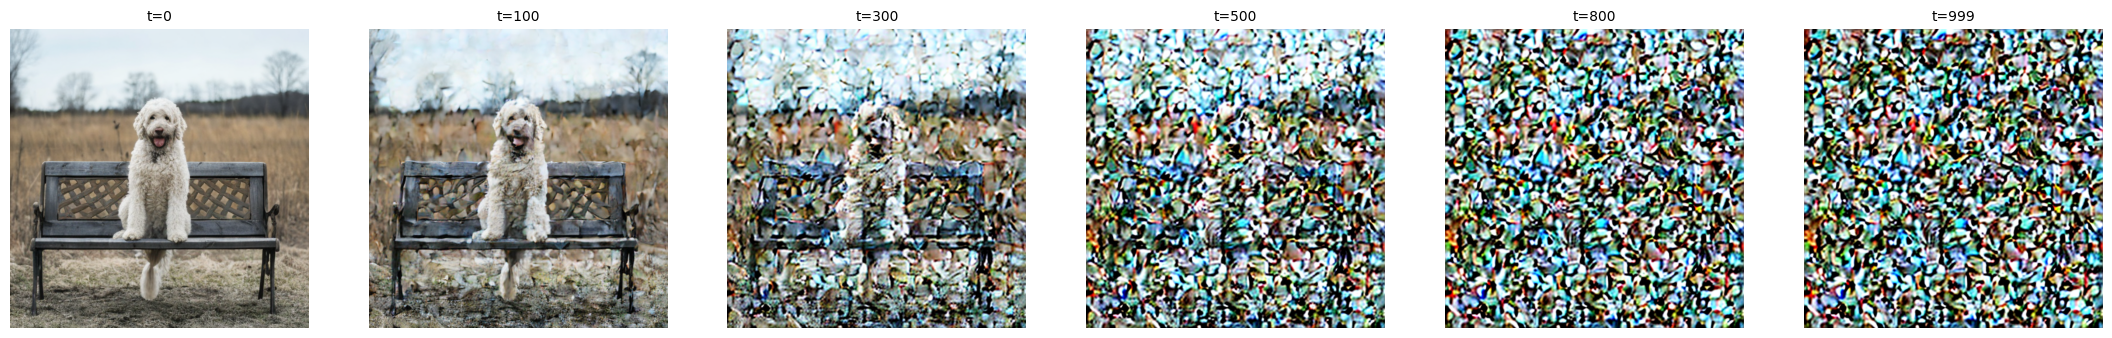

In [9]:
ts = [0, 100, 300, 500, 800, 999]
eps = torch.randn_like(z)
noised = []
for t in ts:
    t_tensor = torch.tensor([t], device=DEVICE)
    x_t = scheduler.add_noise(z, eps, t_tensor)
    noised.append(decode(x_t))
show(*noised, titles=[f't={t}' for t in ts])


### Task 2.2 — Plot the schedule and the SNR
`scheduler.alphas_cumprod` is the $\bar\alpha_t$ curve (length 1000). The per-step **signal-to-noise ratio** is $\text{SNR}(t)=\bar\alpha_t/(1-\bar\alpha_t)$.
> **TODO:** Plot $\bar\alpha_t$ vs $t$, and $\log \text{SNR}(t)$ vs $t$, as two curves.

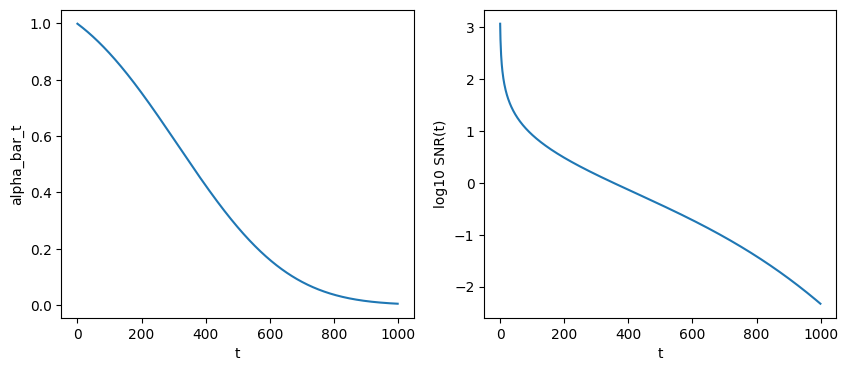

In [10]:
ac = scheduler.alphas_cumprod.cpu().numpy()
t_axis = np.arange(len(ac))
snr = ac / (1 - ac)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(t_axis, ac)
axes[0].set_xlabel('t')
axes[0].set_ylabel('alpha_bar_t')
axes[1].plot(t_axis, np.log10(snr))
axes[1].set_xlabel('t')
axes[1].set_ylabel('log10 SNR(t)')
plt.show()


> **Q2.** (a) From the equation, write the mean and variance of $x_t$ in terms of $\bar\alpha_t$. (b) Because the schedule keeps $\text{mean}^2+\text{var}$ roughly constant, this is called a *variance-preserving* process — verify this qualitatively from your plot. (c) At which end of the $t$ axis is the U-Net's denoising job hardest, and why?

*Your answer to Q2:*

(a) mean is $\sqrt{\bar\alpha_t}\,x_0$ and variance is $(1-\bar\alpha_t)\mathbf I$.

(b) if $x_0$ has roughly unit variance the total variance of $x_t$ is $\text{mean}^2+\text{var}=\bar\alpha_t\,x_0^2+(1-\bar\alpha_t)\approx \bar\alpha_t+(1-\bar\alpha_t)=1$ for all $t$ so the process keeps the total signal plus noise variance close to constant that this is exactly the "variance preserving" property and visible in the plot as $\bar\alpha_t$ smoothly decaying from 1 toward 0 while the added noise variance $1-\bar\alpha_t$ grows to compensate

(c) denoising job is hardest near $t=T$ (large $t$) because $\bar\alpha_t\to0$ there so the SNR $=\bar\alpha_t/(1-\bar\alpha_t)$ collapses toward 0 means very negative on the log SNR plot and latent is almost pure noise and U Net must recover global structure with almost no signal to anchor on


## Part 3 — The reverse process, by hand
Sampling = start from pure noise $x_T$ and iteratively denoise. At each step the **U-Net** predicts the noise $\epsilon_\theta(x_t,t,c)$ and the **sampler** (`scheduler.step`) uses it to estimate $x_{t-1}$. You will write this loop yourself instead of calling `pipe(...)`.

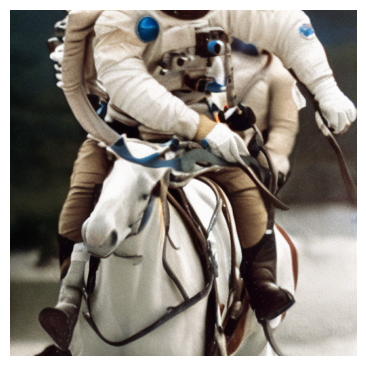

In [11]:
@torch.no_grad()
def embed(prompt):
    tok = tokenizer(prompt, padding='max_length', max_length=tokenizer.model_max_length,
                    truncation=True, return_tensors='pt').input_ids.to(DEVICE)
    return text_encoder(tok)[0]                          # [1, 77, 1024]

@torch.no_grad()
def sample(prompt, steps=25, guidance=7.5, seed=0):
    cond, uncond = embed(prompt), embed('')
    emb = torch.cat([uncond, cond])                      # batch the two passes
    gen = torch.Generator(DEVICE).manual_seed(seed)
    x = torch.randn((1, unet.config.in_channels, 64, 64),
                    generator=gen, device=DEVICE, dtype=DTYPE)
    scheduler.set_timesteps(steps)
    x = x * scheduler.init_noise_sigma
    for t in scheduler.timesteps:
        inp = scheduler.scale_model_input(torch.cat([x] * 2), t)
        eps_uncond, eps_cond = unet(inp, t, encoder_hidden_states=emb).sample.chunk(2)
        # --- classifier-free guidance (you edit this line in Part 4) ---
        eps = eps_uncond + guidance * (eps_cond - eps_uncond)
        x = scheduler.step(eps, t, x).prev_sample
    return decode(x)

show(sample('a photograph of an astronaut riding a horse', steps=25, seed=0))

### Task 3.1 — Steps vs. quality (sampler as an ODE solver)
DDIM is a deterministic solver of the probability-flow ODE; fewer steps = coarser integration.
> **TODO:** Generate the **same prompt and seed** at `steps in [4, 10, 25, 50]`, timing each, and display the four results with their wall-clock times in the titles.

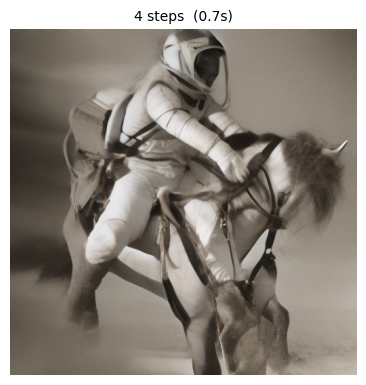

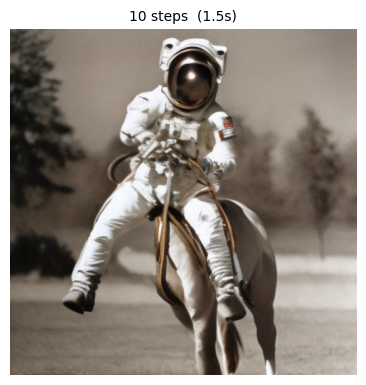

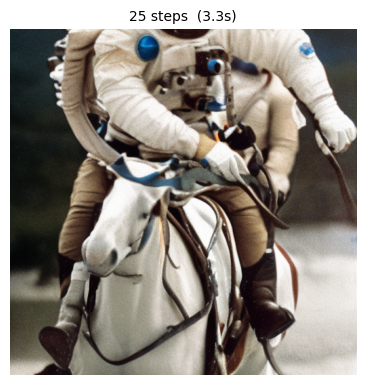

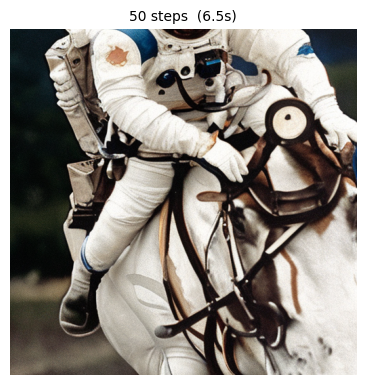

In [12]:
prompt = 'a photograph of an astronaut riding a horse'
for s in [4, 10, 25, 50]:
    t0 = time.time(); out = sample(prompt, steps=s, seed=0); dt = time.time() - t0
    show(out, titles=[f'{s} steps  ({dt:.1f}s)'])


> **Q3.** Explain why DDIM produces a coherent image in ~10-25 steps while the original DDPM sampler needs hundreds. Frame your answer in terms of *deterministic vs. stochastic* sampling and step size of the ODE solver.

*Your answer to Q3:*

DDIM defines a deterministic mapping that follows the probability flow ODE associated with diffusion process so each sampling step is just one step of numerical ODE integration and because the trajectory is smooth and deterministic a coarse discretization still tracks it closely enough to land near a high quality solution and original DDPM sampler instead simulates the full stochastic reverse Markov chain and re injecting random noise at every step that stochasticity means the trajectory is much less smooth so the discretization needs many small steps to keep the accumulated integration/stochastic error small enough to converge to a good sample


## Part 4 — Classifier-free guidance (CFG)
The guidance line in `sample()` implements

$$\hat\epsilon=\epsilon_\theta(x_t,\varnothing)+s\,\big(\epsilon_\theta(x_t,c)-\epsilon_\theta(x_t,\varnothing)\big)$$

where $s$ is `guidance` and $\varnothing$ is the empty prompt. The model is trained with random prompt-dropout so it can produce both $\epsilon_\theta(x_t,c)$ and $\epsilon_\theta(x_t,\varnothing)$.

### Task 4.1 — Sweep the guidance scale
> **TODO:** Fix prompt + seed and generate at `guidance in [1, 3, 7.5, 15, 25]`. Show all five. Note the washed-out image at `s=1` and the over-saturated, high-contrast artefacts at `s=25`.

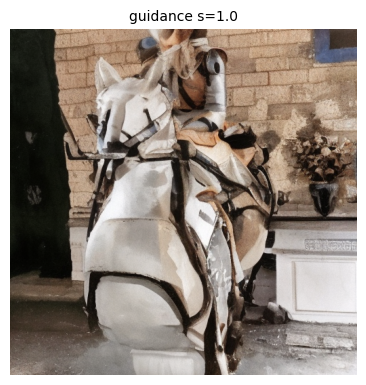

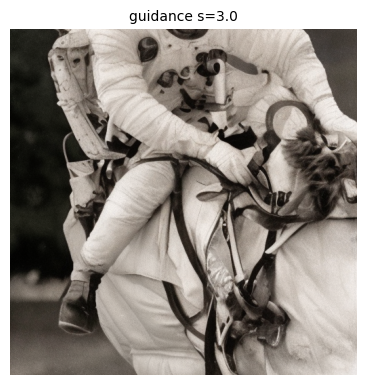

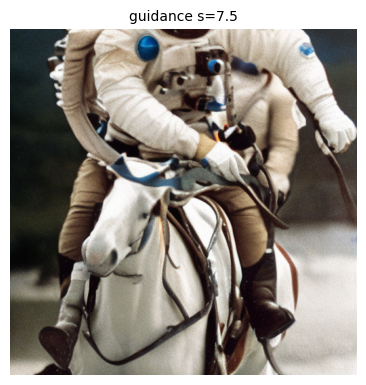

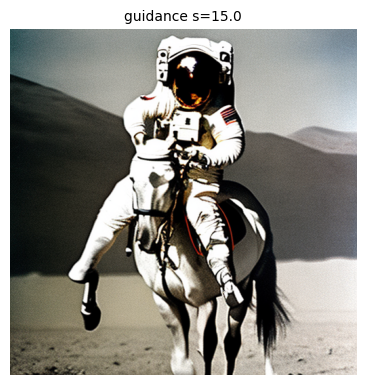

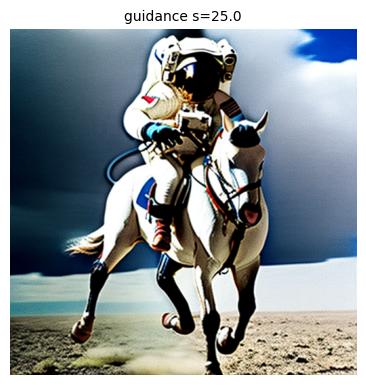

In [13]:
for g in [1.0, 3.0, 7.5, 15.0, 25.0]:
    show(sample(prompt, steps=25, guidance=g, seed=0), titles=[f'guidance s={g}'])


> **Q4.** (a) What image does `s=1` correspond to (look at the equation)? (b) Rewrite $\hat\epsilon$ as an extrapolation between the unconditional and conditional predictions, and use that to explain the over-saturation at large `s`. (c) InstructPix2Pix (Part 6) uses a **triple** guidance with separate scales $s_T$ (text) and $s_I$ (image):
$$\hat\epsilon=\epsilon(x,\varnothing,\varnothing)+s_I\big(\epsilon(x,c_I,\varnothing)-\epsilon(x,\varnothing,\varnothing)\big)+s_T\big(\epsilon(x,c_I,c_T)-\epsilon(x,c_I,\varnothing)\big).$$
Map $s_T$ and $s_I$ onto the intuitive knobs "follow the instruction more" and "stay closer to the input image."

*Your answer to Q4:*

(a) \epsilon_\theta(x_t,c)$ means plain conditional sampling with no extra guidance so a vanilla conditional model output

(b) $\hat\epsilon$ is a point on the line through $\epsilon_\theta(x_t,\varnothing)$ and $\epsilon_\theta(x_t,c)$ parameterized by $s$ and for $s>1$ this is an extrapolation past the conditional prediction in the direction away from the unconditional one and pushing $s$ large drives the estimate further outside the region the model was actually trained to predict accurately exaggerating conditioning aligned features and amplifying magnitudes which shows up as oversaturated colors harsh contrast and artifacts

(c) $s_I$ multiplies the term that measures how much conditioning on the input image beyond the fully unconditional prediction matters so it makes stay closer to the input image and $s_T$ multiplies the term that measures how much adding the text instruction beyond image only conditioning matters so it means follow the instruction more


## Part 5 — Conditioning: CLIP embeddings and cross-attention
The text prompt enters the U-Net only through **cross-attention** to the CLIP text embedding (shape `77 x 1024`: 77 token slots, 1024-dim each). Here we probe that embedding space.

### Task 5.1 — Prompt similarity
> **TODO:** Embed three prompts (two similar, one different), mean-pool over the 77 tokens to get one vector each, and print the pairwise **cosine similarities**.

In [14]:
import torch.nn.functional as Fn
prompts = ['a photo of a cat', 'a photo of a kitten', 'a photo of a truck']
vecs = [embed(p).mean(dim=1) for p in prompts]
for i in range(len(prompts)):
    for j in range(i + 1, len(prompts)):
        sim = Fn.cosine_similarity(vecs[i], vecs[j])
        print(prompts[i], prompts[j], sim.item())


a photo of a cat a photo of a kitten 0.994140625
a photo of a cat a photo of a truck 0.986328125
a photo of a kitten a photo of a truck 0.98095703125


### Task 5.2 — Interpolating in embedding space
Because conditioning is a continuous vector, we can walk *between* two prompts.
> **TODO:** Build a modified sampler that accepts a precomputed conditional embedding, then linearly interpolate `emb = (1-a)*embA + a*embB` for `a in [0, 0.25, 0.5, 0.75, 1.0]` (same seed) and show the semantic morph.

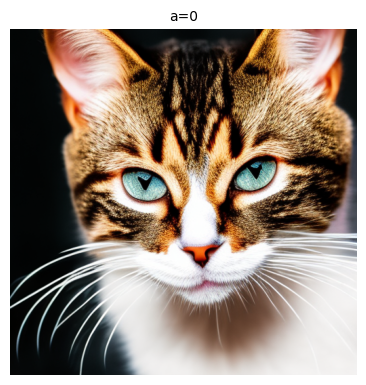

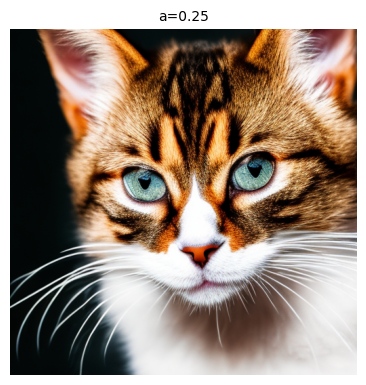

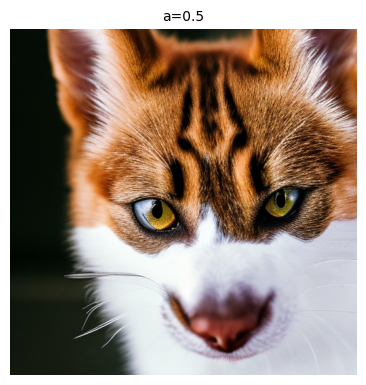

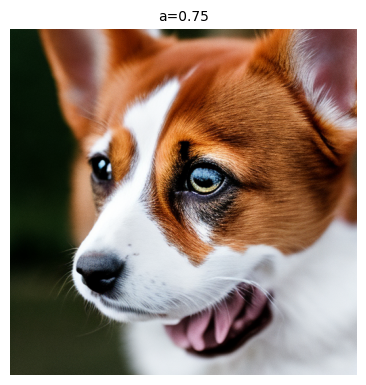

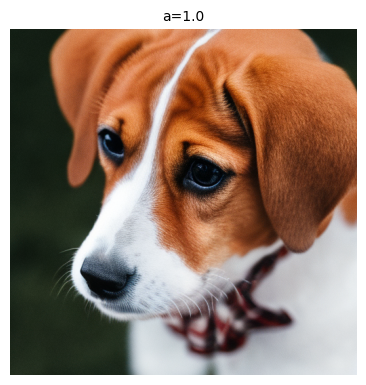

In [15]:
@torch.no_grad()
def sample_emb(cond, steps=25, guidance=7.5, seed=0):
    emb = torch.cat([embed(''), cond])
    gen = torch.Generator(DEVICE).manual_seed(seed)
    x = torch.randn((1, unet.config.in_channels, 64, 64),
                    generator=gen, device=DEVICE, dtype=DTYPE)
    scheduler.set_timesteps(steps); x = x * scheduler.init_noise_sigma
    for t in scheduler.timesteps:
        inp = scheduler.scale_model_input(torch.cat([x] * 2), t)
        eu, ec = unet(inp, t, encoder_hidden_states=emb).sample.chunk(2)
        x = scheduler.step(eu + guidance * (ec - eu), t, x).prev_sample
    return decode(x)

embA, embB = embed('a photo of a cat'), embed('a photo of a dog')
for a in [0, .25, .5, .75, 1.]:
    show(sample_emb((1 - a) * embA + a * embB, seed=0), titles=[f'a={a}'])


> **Q5.** Cross-attention lets *each spatial location* of the latent attend to the 77 text tokens. Using your Task 5.2 morph, argue whether the transition is *semantic* (the concept changes) or merely a *pixel blend* of two images, and say what that implies about where meaning lives in this model.

*Your answer to Q5:*

morph looks semantic rather than a pixel blend because the interpolated embedding is fed into cross attention at every denoising step of the whole generation and not applied once to two finished images and it steers the entire generative trajectory in latent space so intermediate values of a produce a single coherent object with mixed features rather than a ghosted double exposure of a cat photo and a dog photo and this implies that meaning in this model is encoded in the conditioning vector and expressed through the cross attention layers that guide the whole synthesis process and not something that lives in pixel space and could be produced by simple image compositing


## Part 6 — Applications: instruction editing and inpainting
Now use two specialised models. First free the base model's VRAM.

In [16]:
free_memory(pipe, unet, vae, text_encoder)
print('freed base model')

freed base model


### Task 6.1 — Iterative instruction editing (InstructPix2Pix)
InstructPix2Pix conditions on the **input image latent** (concatenated to the U-Net input) *and* a text instruction — the triple-CFG model from Q4.
> **TODO:** Apply a chain of **≥3 successive instructions**, feeding each output back in. Show all steps.

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

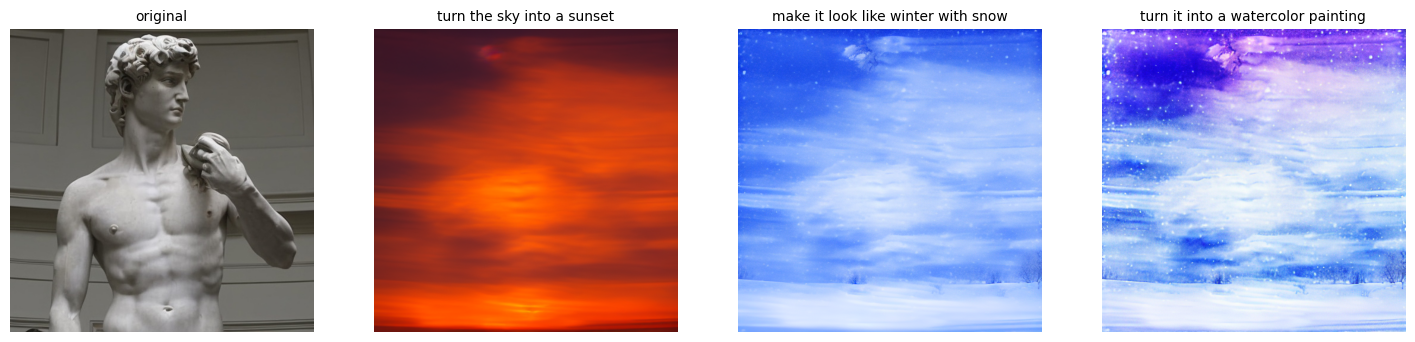

In [24]:
from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler
ip2p = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    'timbrooks/instruct-pix2pix', torch_dtype=DTYPE, safety_checker=None).to(DEVICE)
ip2p.scheduler = EulerAncestralDiscreteScheduler.from_config(ip2p.scheduler.config)
ip2p.set_progress_bar_config(disable=True)

base_img = load_image('https://raw.githubusercontent.com/timothybrooks/instruct-pix2pix/'
                      'main/imgs/example.jpg')
instructions = ['turn the sky into a sunset', 'make it look like winter with snow', 'turn it into a watercolor painting']
current = base_img
results = [current]
for instr in instructions:
    current = ip2p(instr, image=current, num_inference_steps=20,
                    image_guidance_scale=1.5, guidance_scale=7.5).images[0]
    results.append(current)
show(*results, titles=['original'] + instructions)


### Task 6.2 — Inpainting and the U-Net input channels
The inpainting U-Net takes **9 input channels** = 4 (noisy latent) + 1 (mask) + 4 (masked-image latent), versus 4 for the base model. That is how it "sees" the hole and the surroundings.

In [23]:
free_memory(ip2p)
from diffusers import StableDiffusionInpaintPipeline

# NOTE: 'stabilityai/stable-diffusion-2-inpainting' was also deprecated/removed (404).
# 'sd2-community/stable-diffusion-2-inpainting' is a mirror of the same weights.
inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    'sd2-community/stable-diffusion-2-inpainting', torch_dtype=DTYPE).to(DEVICE)
inpaint.set_progress_bar_config(disable=True)
print('inpaint U-Net in_channels:', inpaint.unet.config.in_channels)   # expect 9

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

inpaint U-Net in_channels: 9


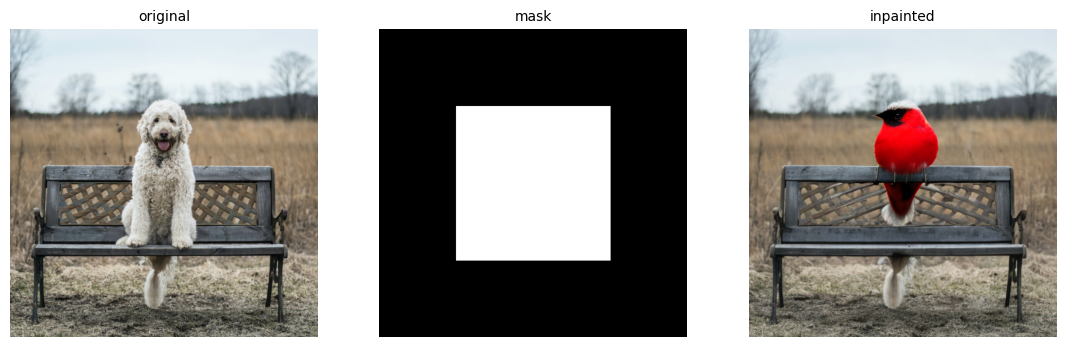

In [22]:
from PIL import ImageDraw
def rect_mask(size, box):
    m = Image.new('L', size, 0); ImageDraw.Draw(m).rectangle(box, fill=255)
    return m.convert('RGB')

mask = rect_mask(img.size, (128, 128, 384, 384))
prompt = 'a small red bird sitting on a branch'
result = inpaint(prompt=prompt, image=img, mask_image=mask, num_inference_steps=25).images[0]
show(img, mask, result, titles=['original', 'mask', 'inpainted'])


> **Q6.** The base text-to-image U-Net has 4 input channels; the inpainting one has 9. Explain what each extra channel group encodes and why a plain text-to-image model *cannot* do clean local inpainting without them.

*Your answer to Q6:*

base text to image U Net input is just 4 channels that is the noisy latent itself and inpainting U Net 9 channels split into the same 4 noisy latent plus 1 mask channel plus 4 masked image latent channels and mask channel tells the network at the resolution of the latent grid exactly which region is missing and needs to be generated versus which region must be preserved and 4 masked image latent channels give the network direct access to the untouched surrounding context that is encoded through the VAE at every single denoising step so the model can condition its noise prediction on the real content right up to the edge of the hole  and a plain text to image model has no such channels and it can only be steered toward preserving known pixels by manually pasting them back in after each step  which does not let the network see the boundary while it plans fill and producing visible seams and inconsistent lighting and mismatched texture at the mask edge


## Part 7 — Failure analysis, tied to a mechanism
> **Q7.** Produce **one** failed generation/edit (show it), then explain the failure using a concept from this notebook — e.g. VAE reconstruction limits (Part 1), too-few sampler steps (Part 3), guidance too high/low (Part 4), or weak cross-attention binding (Part 5). Name the mechanism explicitly.

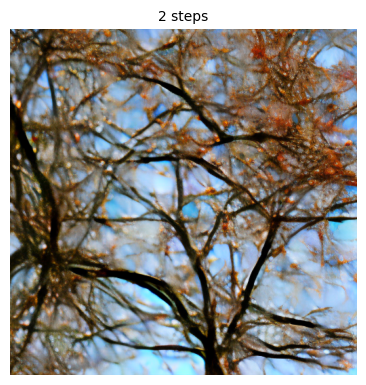

In [21]:
show(sample(prompt, steps=2, guidance=7.5, seed=0), titles=['2 steps'])


*Your answer to Q7:*

this running sample() with only 2 DDIM steps produces a blurry and structurally incoherent image instead of a recognizable astronaut on a horse scene and mechanism is the one from Part 3 that DDIM is a numerical solver for the probability flow ODE and with only 2 steps the integration is far too coarse to track that ODE trajectory accurately so the sampler never converges to a point in the high density region of the data manifold and it stops at an under denoised intermediate state unlike the 25-50 step runs which integrate finely enough to land on a coherent image


---
## Submission
1. `Runtime > Run all` so every plot and image renders.
2. `File > Download > Download .ipynb` **with outputs saved**.
3. Submit the `.ipynb` with Q1-Q7 answered. Cleared outputs are auto-zero.